In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
import sys

In [2]:
sys.path.append(r"C:\Users\xylin\Documents\Researches\multiphonon-direct-detection\StructureFactor1D.py")
from StructureFactor1D import StructureFactor1D

In [3]:

# def spring(start, end, nodes, width):
#     """!
#     Return a list of points corresponding to a spring.

#     @param r1 (array-like) The (x, y) coordinates of the first endpoint.
#     @param r2 (array-like) The (x, y) coordinates of the second endpoint.
#     @param nodes (int) The number of spring "nodes" or coils.
#     @param width (int or float) The diameter of the spring.
#     @return An array of x coordinates and an array of y coordinates.
#     """

#     # Check that nodes is at least 1.
#     nodes = max(int(nodes), 1)

#     # Convert to numpy array to account for inputs of different types/shapes.
#     start, end = np.array(start).reshape((2,)), np.array(end).reshape((2,))

#     # If both points are coincident, return the x and y coords of one of them.
#     if (start == end).all():
#         return start[0], start[1]

#     # Calculate length of spring (distance between endpoints).
#     length = np.linalg.norm(np.subtract(end, start))

#     # Calculate unit vectors tangent (u_t) and normal (u_t) to spring.
#     u_t = np.subtract(end, start) / length
#     u_n = np.array([[0, -1], [1, 0]]).dot(u_t)

#     # Initialize array of x (row 0) and y (row 1) coords of the nodes+2 points.
#     spring_coords = np.zeros((2, nodes + 2))
#     spring_coords[:,0], spring_coords[:,-1] = start, end

#     # Check that length is not greater than the total length the spring
#     # can extend (otherwise, math domain error will result), and compute the
#     # normal distance from the centerline of the spring.
#     normal_dist = math.sqrt(max(0, width**2 - (length**2 / nodes**2))) / 2

#     # Compute the coordinates of each point (each node).
#     for i in range(1, nodes + 1):
#         spring_coords[:,i] = (
#             start
#             + ((length * (2 * i - 1) * u_t) / (2 * nodes))
#             + (normal_dist * (-1)**i * u_n))

#     return spring_coords[0,:], spring_coords[1,:]

In [4]:

def spring(start, end, coils=10, width=0.5, nodes=500, ):
    """
    Generates a 2D spring that looks 3D by projecting a helix.
    """
    start = np.array(start)
    end = np.array(end)
    vector = end - start
    length = np.linalg.norm(vector)
    unit_vector = vector / length
    
    normal = np.array([-unit_vector[1], unit_vector[0]])

    t = np.linspace(0, 1, nodes)
    
    line_points = start[np.newaxis, :] + t[:, np.newaxis] * vector
    theta = 2 * np.pi * coils * t
    longitudinal_offset = (width * 0.3) * np.cos(theta)
    
    # Lateral offset (the actual width of the spring)
    lateral_offset = width * np.sin(theta)
    
    # Combine everything
    spring_x = line_points[:, 0] + longitudinal_offset * unit_vector[0] + lateral_offset * normal[0]
    spring_y = line_points[:, 1] + longitudinal_offset * unit_vector[1] + lateral_offset * normal[1]
    
    return spring_x, spring_y

In [5]:
def curved_spring(start, end, height=2.0, coils=25, width=0.4, nodes=1000):
    """
    Generates a curved 2D spring by wrapping coils around a parabolic path.
    """
    start = np.array(start)
    end = np.array(end)
    vector = end - start
    length = np.linalg.norm(vector)
    unit_vector = vector / length
    global_normal = np.array([-unit_vector[1], unit_vector[0]])

    t = np.linspace(0, 1, nodes)
    
    # 1. Define the parabolic spine of the curve
    line_points = start[np.newaxis, :] + t[:, np.newaxis] * vector
    curve_offset = 4 * height * t * (1 - t) # Parabola peaking at 'height'
    curve_points = line_points + curve_offset[:, np.newaxis] * global_normal[np.newaxis, :]

    # 2. Calculate local tangent and normal along the curve for realistic coiling
    tangent_x = length * unit_vector[0] + 4 * height * (1 - 2*t) * global_normal[0]
    tangent_y = length * unit_vector[1] + 4 * height * (1 - 2*t) * global_normal[1]
    tangent = np.column_stack((tangent_x, tangent_y))
    
    # Normalize tangents to get consistent coil widths
    tangent_norms = np.linalg.norm(tangent, axis=1)
    unit_tangent = tangent / tangent_norms[:, np.newaxis]
    unit_normal = np.column_stack((-unit_tangent[:, 1], unit_tangent[:, 0]))

    # 3. Add the helical coils
    theta = 2 * np.pi * coils * t
    longitudinal_offset = (width * 0.3) * np.cos(theta)
    lateral_offset = width * np.sin(theta)

    spring_x = curve_points[:, 0] + longitudinal_offset * unit_tangent[:, 0] + lateral_offset * unit_normal[:, 0]
    spring_y = curve_points[:, 1] + longitudinal_offset * unit_tangent[:, 1] + lateral_offset * unit_normal[:, 1]

    return spring_x, spring_y

In [6]:
def draw_potential(ax, origin, x_len, y_len):
    """
    Plots a potential well (parabola) labeled with kappa^2/2 on an existing axis.
    
    Parameters:
    ax: matplotlib.axes.Axes object to plot on.
    origin: tuple (x0, y0) representing the center/vertex of the potential.
    x_len: float, the total horizontal span of the x-axis arrow.
    y_len: float, the total vertical height of the y-axis arrow.
    """
    x0, y0 = origin
    
    # Calculate parabola points centered at the origin
    # We plot it up to ~80% of the arrow length for visual clarity
    x_span = x_len * 0.4
    x_vals = np.linspace(x0 - x_span, x0 + x_span, 100)
    
    # Define a scaling factor so the parabola fits within the y_len
    # y = a(x - x0)^2 + y0
    a = (y_len * 0.7) / (x_span**2)
    y_vals = a * (x_vals - x0)**2 + y0
    
    # 1. Plot the potential curve
    ax.plot(x_vals, y_vals, color='tab:blue', linewidth=2)
    
    # 2. Draw the x-axis arrow (horizontal)
    ax.annotate('', xy=(x0 + x_len/2, y0), xytext=(x0 - x_len/2, y0),
                arrowprops=dict(arrowstyle='->', color='tab:blue', lw=1.5))
    
    # 3. Draw the y-axis arrow (vertical)
    ax.annotate('', xy=(x0, y0 + y_len), xytext=(x0, y0 - 0.35 * y_len),
                arrowprops=dict(arrowstyle='->', color='tab:blue', lw=1.5))
    
    # 4. Add the kappa^2/2 label
    ax.text(x0 + x_len * 0.15, y0 + y_len * 0.8, r'$\frac{1}{2}\gamma x^2$', fontsize=16, color="tab:blue")

# Example Usage:
# fig, ax = plt.subplots()
# draw_potential(ax, origin=(5, 2), x_len=4, y_len=6)
# plt.show()

In [7]:
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'mathtext.fontset': 'stix', 
    'font.size': 17              
})

(-0.9, 2.9, -1.5, 1.5)

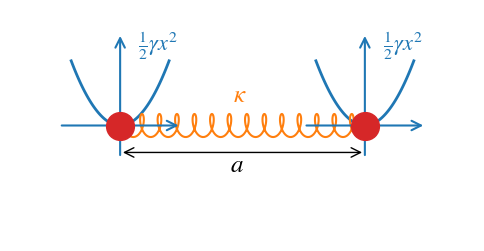

In [8]:
site1_coordx = 0
site1_coordy = 0 
site2_coordx = 2
site2_coordy = 0 
sp_len = 0.3
# sp1x,sp1y = spring((site1_coordx-sp_len,site1_coordy), (site1_coordx, site1_coordy), 12, 0.2, )
# sp2x,sp2y = spring((site2_coordx-sp_len,site2_coordy), (site2_coordx, site2_coordy), 12, 0.2, )
sp3x,sp3y = spring((site1_coordx, site1_coordx), (site2_coordx, site2_coordy), 14, 0.15)

fig, ax = plt.subplots(figsize=(6,3))
# plt.text(site1_coordx-sp_len/1.2,site1_coordy+sp_len/1.5,r"$\kappa$",fontsize="18",color="tab:blue")
# plt.text(site2_coordx-sp_len/1.2,site2_coordy+sp_len/1.5,r"$\kappa$",fontsize="18",color="tab:blue")
plt.text((site1_coordx+site2_coordx)/2-sp_len/4,(site1_coordy+site2_coordy)/2+sp_len,r"$\kappa$",fontsize="18",color="tab:orange")
plt.text(.9,-.6,r"$a$",fontsize="18",color="black")
ax.annotate("",
            xy=(0., -0.35), xycoords='data',
            xytext=(2, -.35), textcoords='data',
            arrowprops=dict(arrowstyle="<->"))
plt.scatter(site1_coordx, site1_coordy, s=400, color="tab:red",zorder=20)
plt.scatter(site2_coordx, site2_coordy, s=400, color="tab:red",zorder=20)
# plt.plot(sp1x,sp1y,color="tab:blue")
# plt.plot(sp2x,sp2y,color="tab:blue")
draw_potential(ax, (site1_coordx,site1_coordy),1,1.2)
draw_potential(ax, (site2_coordx,site2_coordy),1,1.2)
plt.plot(sp3x,sp3y,color="tab:orange")
plt.xlim(-.9,2.9)
plt.ylim(-1.5,1.5)
plt.axis('off')


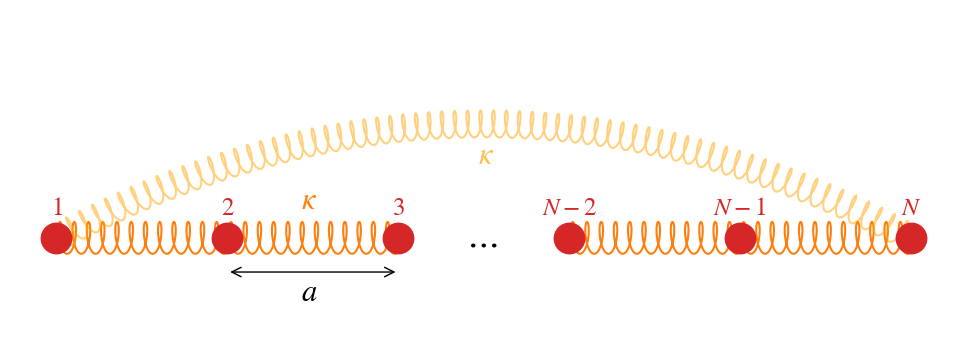

In [9]:
fig, ax = plt.subplots(figsize=(10, 4))

# Define particle positions
spacing = 1.5
p1 = (0, 0)
p2 = (spacing, 0)
p3 = (2 * spacing, 0)

# The gap where the "..." will go
gap = 1.5

p4 = (2 * spacing + gap, 0)
p5 = (3 * spacing + gap, 0)
p6 = (4 * spacing + gap, 0)

sx1, sy1 = spring(p1, p2, 12, 0.14)
sx2, sy2 = spring(p2, p3, 12, 0.14)
sx3, sy3 = spring(p4, p5, 12, 0.14)
sx4, sy4 = spring(p5, p6, 12, 0.14)

ax.plot(sx1, sy1, color='tab:orange', lw=1.5, zorder=1)
ax.plot(sx2, sy2, color='tab:orange', lw=1.5, zorder=1)
ax.plot(sx3, sy3, color='tab:orange', lw=1.5, zorder=1)
ax.plot(sx4, sy4, color='tab:orange', lw=1.5, zorder=1)

# 2. Draw the large curved spring connecting p1 and p6
cx, cy = curved_spring(p1, p6, height=1., coils=67, width=0.12,)
ax.plot(cx, cy, color='orange', lw=1.5, zorder=1,alpha=.5)

# 3. Draw the particles (Slightly smaller size: s=400)
points = [p1, p2, p3, p4, p5, p6]
x_coords = [p[0] for p in points]
y_coords = [p[1] for p in points]
ax.scatter(x_coords, y_coords, s=480, color='tab:red', zorder=2)

# 4. Add the "..." in the middle
ax.text((p3[0] + p4[0]) / 2, 0, '...', fontsize=30, ha='center', va='center')

# 5. Add subscript labels matching standard notation
# labels = ['$\kappa$', '$\kappa$', '$\kappa$', '$\kappa$', '$\kappa$', ]
# for x, label in zip(x_coords[:-1], labels):
    # ax.text(x+gap/2, .6, label, ha='center', color="tab:orange")
plt.text(2.15,.25,r"$\kappa$",fontsize="22",color="tab:orange")
plt.text(3.7,.65,r"$\kappa$",fontsize="22",color="orange", alpha=.7)

plt.text(2.15,-.55,r"$a$",fontsize="22",color="black")
ax.annotate("", 
            xy=(p3[0], -0.3), xycoords='data', 
            xytext=(p2[0], -0.3), textcoords='data', 
            arrowprops=dict(arrowstyle="<->", linewidth=1.))

labels = ['$1$', '$2$', '$3$', '${N-2}$', '${N-1}$', '$N$']
for x, label in zip(x_coords, labels):
    ax.text(x, .2, label, fontsize=18, ha='center', color="tab:red")

# Clean up the plot axes for a schematic look
ax.set_aspect('equal')
ax.axis('off')
ax.set_ylim(-.8, 2.0)
plt.tight_layout()
plt.show()

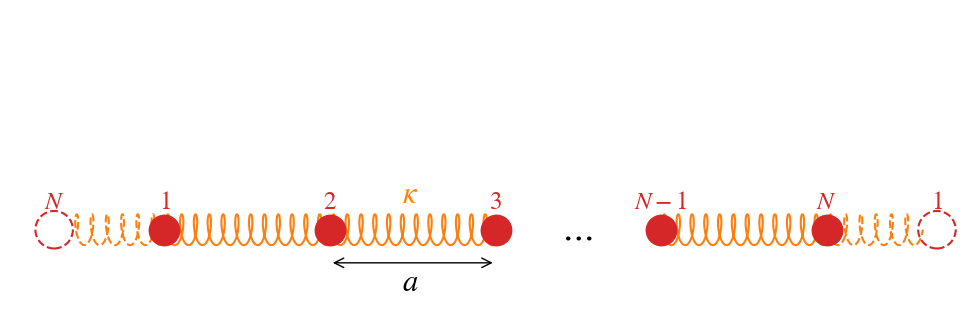

In [24]:
from matplotlib.patches import Circle

def spring(start, end, coils=10, width=0.5, nodes=500):
    """
    Generates a 2D spring that looks 3D by projecting a helix.
    """
    start = np.array(start)
    end = np.array(end)
    vector = end - start
    length = np.linalg.norm(vector)
    unit_vector = vector / length

    normal = np.array([-unit_vector[1], unit_vector[0]])

    t = np.linspace(0, 1, nodes)
    line_points = start[np.newaxis, :] + t[:, np.newaxis] * vector
    theta = 2 * np.pi * coils * t
    longitudinal_offset = (width * 0.3) * np.cos(theta)
    lateral_offset = width * np.sin(theta)

    spring_x = line_points[:, 0] + longitudinal_offset * unit_vector[0] + lateral_offset * normal[0]
    spring_y = line_points[:, 1] + longitudinal_offset * unit_vector[1] + lateral_offset * normal[1]
    return spring_x, spring_y

fig, ax = plt.subplots(figsize=(10, 4))

# Define particle positions
spacing = 1.5
p1 = (0, 0)
p2 = (spacing, 0)
p3 = (2 * spacing, 0)

gap = 1.5
# N-1 sits where N-2 used to be, so the "..." gap matches the original
p5 = (2 * spacing + gap, 0)
p6 = (3 * spacing + gap, 0)

sx1, sy1 = spring(p1, p2, 12, 0.14)
sx2, sy2 = spring(p2, p3, 12, 0.14)
sx4, sy4 = spring(p5, p6, 12, 0.14)

ax.plot(sx1, sy1, color='tab:orange', lw=1.5, zorder=1)
ax.plot(sx2, sy2, color='tab:orange', lw=1.5, zorder=1)
ax.plot(sx4, sy4, color='tab:orange', lw=1.5, zorder=1)

# 2. Ghost node + dashed spring in front of particle 1 (labeled N)
circle_radius = 0.17
left_center = (-1.0, 0)
gsx1, gsy1 = spring((left_center[0] + circle_radius, 0), p1, 6, 0.14)
ax.plot(gsx1, gsy1, color='tab:orange', lw=1.5, ls='--', zorder=1)
ax.add_patch(Circle(left_center, circle_radius, fill=False,
                    edgecolor='tab:red', lw=1.5, ls='--', zorder=2))
ax.text(left_center[0], .2, r'$N$', fontsize=18,
        ha='center', color='tab:red')

# 2b. Ghost node + dashed spring after particle N (labeled 1)
right_center = (p6[0] + 1.0, 0)
gsx2, gsy2 = spring(p6, (right_center[0] - circle_radius, 0), 6, 0.14)
ax.plot(gsx2, gsy2, color='tab:orange', lw=1.5, ls='--', zorder=1)
ax.add_patch(Circle(right_center, circle_radius, fill=False,
                    edgecolor='tab:red', lw=1.5, ls='--', zorder=2))
ax.text(right_center[0], .2, r'$1$', fontsize=18,
        ha='center', color='tab:red')

# 3. Draw the particles
points = [p1, p2, p3, p5, p6]
x_coords = [p[0] for p in points]
y_coords = [p[1] for p in points]
ax.scatter(x_coords, y_coords, s=480, color='tab:red', zorder=2)

# 4. Add the "..." in the middle
ax.text((p3[0] + p5[0]) / 2, 0, '...', fontsize=30, ha='center', va='center')

# 5. Labels
plt.text(2.15, .25, r"$\kappa$", fontsize="22", color="tab:orange")

plt.text(2.15, -.55, r"$a$", fontsize="22", color="black")
ax.annotate("",
            xy=(p3[0], -0.3), xycoords='data',
            xytext=(p2[0], -0.3), textcoords='data',
            arrowprops=dict(arrowstyle="<->", linewidth=1.))

labels = ['$1$', '$2$', '$3$', '${N-1}$', '$N$']
for x, label in zip(x_coords, labels):
    ax.text(x, .2, label, fontsize=18, ha='center', color="tab:red")

# Clean up
ax.set_aspect('equal')
ax.axis('off')
ax.set_xlim(-1.4, 7.2)
ax.set_ylim(-.8, 2.0)
plt.tight_layout()
plt.show()

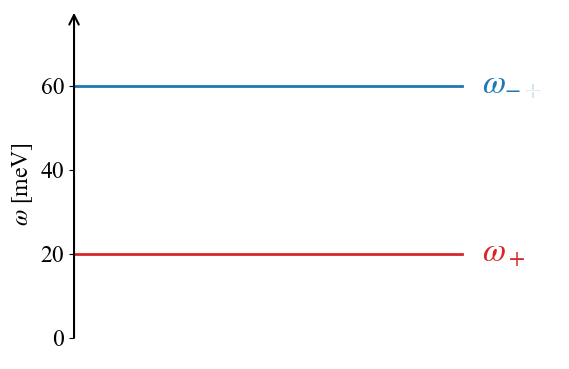

In [11]:
ffig, ax = plt.subplots(figsize=(6, 4))
# Plot horizontal lines
ax.axhline(y=60,xmin=0,xmax=0.8, color='tab:blue', linestyle='-', linewidth=2)
ax.text(.8, 60, r'$\omega_{- +}$', va='center', ha='left', color='tab:blue',fontsize=24 ,)
ax.text(.882, 60.07, r'$_{+}$', va='center', ha='left', color='white',fontsize=24 ,alpha=1,zorder=200)
 
ax.axhline(y=20, xmin=0,xmax=0.8,color='tab:red', linestyle='-', linewidth=2)
ax.text(.8, 20, r'$\omega_+$', va='center', ha='left', color='tab:red', fontsize=24 )

# Set axis limits and labels
ax.set_ylim(-5, 78)
ax.set_xlim(0, .95)
ax.set_ylabel('$\omega$ [meV]', )

# Only one vertical y-axis. Hide the top and right spines.
ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
# Hide x-axis ticks
ax.set_xticks([])
# ax.set_yticks([20,40,60],[20,40,60])
ax.annotate('', xy=(0, 78), xytext=(0, -0.6),
            arrowprops=dict(arrowstyle="->", color='black', lw=1.5),
            xycoords='data', textcoords='data')
# Title
# ax.set_title('Energy Levels', fontsize=14)

# Adjust layout
plt.tight_layout()



In [12]:
multplier = 1.5
q_value  = multplier*np.sqrt(2*26161e3*13.13e-6) # uses averaged omega (not inverse of averaged inverse)

xlength = 100 # length of xlist used for plotting. Also changes the size of bin 
nLattice = 8000

test = StructureFactor1D(nLattice = nLattice,q_value=q_value, couplingConst=28,)
counts, bin_edges = np.histogram(test.omegaList, bins=50,)
bin_edges = bin_edges*1e6
widths = np.diff(bin_edges)
total_area = np.sum(counts * widths)
xlst = (bin_edges[:-1]+widths/2)


Text(0, 0.5, '$D(\\omega)$ [meV$^{-1}$]')

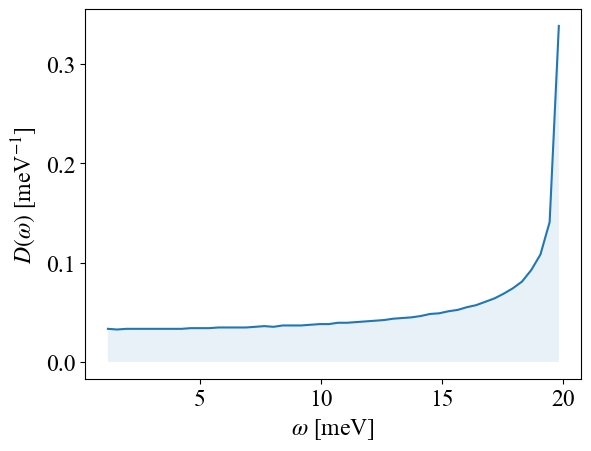

In [13]:
plt.plot(xlst,counts/total_area)
plt.fill_between(xlst,counts/total_area, 0,alpha=.1)

plt.xlabel(r"$\omega$ [meV]")
plt.ylabel(r"$D(\omega)$ [meV$^{-1}$]")

Text(0, 0.5, '$D(\\omega)/\\omega$ [meV$^{-2}$]')

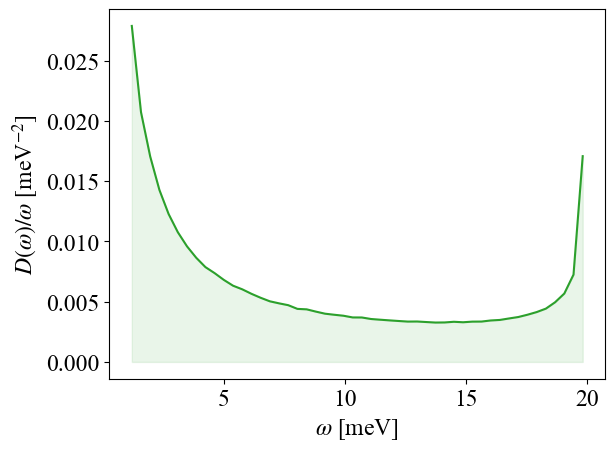

In [14]:
plt.plot(xlst,counts/total_area/xlst, color="tab:green")
plt.fill_between(xlst,counts/total_area/xlst, 0,alpha=.1,color="tab:green")
plt.xlabel(r"$\omega$ [meV]")
plt.ylabel(r"$D(\omega)/\omega$ [meV$^{-2}$]")

Text(0.5, 0, '$k_\\nu$ [keV]')

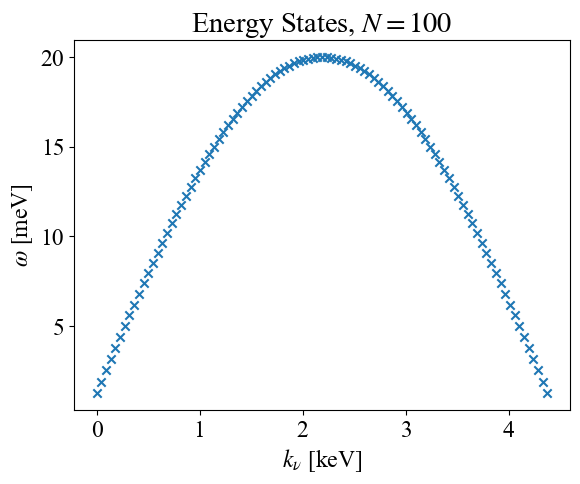

In [15]:
multplier = 1.5
q_value  = multplier*np.sqrt(2*26161e3*13.13e-6) # uses averaged omega (not inverse of averaged inverse)

xlength = 100 # length of xlist used for plotting. Also changes the size of bin 
nLattice = 100

test = StructureFactor1D(nLattice = nLattice,q_value=q_value, couplingConst=28,)
plt.scatter(2*np.pi*np.arange(len(test.omegaList))/50/2.755783029464731, test.omegaList*1e6,marker="x")
plt.title("Energy States, $N = 100$")
plt.ylabel(r"$\omega$ [meV]")
plt.xlabel(r'$k_\nu$ [keV]')

Text(0.5, 0, '$k_\\nu$ [keV]')

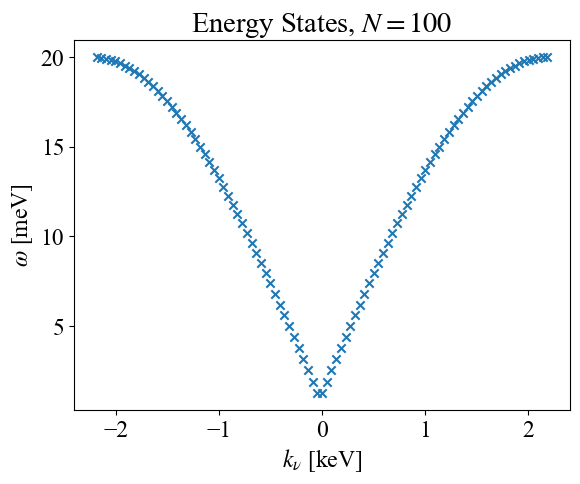

In [25]:
k = 2*np.pi*np.arange(len(test.omegaList))/50/2.755783029464731

dk     = k[1] - k[0]
period = dk*len(k)          # full period = 2*qbz
k      = np.where(k >= period/2, k - period, k)   # shift qbz..2qbz down to -qbz..0

plt.scatter(k, test.omegaList*1e6, marker="x")
plt.title("Energy States, $N = 100$")
plt.ylabel(r"$\omega$ [meV]")
plt.xlabel(r'$k_\nu$ [keV]')